# Проведение расчетов для нескольких населенных пунктов

Зачастую перед пользователем встает задача одновременного (пакетного) проведения расчета нескольких населенных пунктов, которые могут также быть соотнесены друг с другом.

Наиболее часто подобная задача встает перед пользователем в случае, если необходимо провести расчет требуемого количества подразделений для некоторого крупного региона включающего ряд населенных пунктов или административных единиц.

Рассмотрим пример подобного расчета.

```{mermaid}
flowchart LR

  subgraph main_data_load[Загрузка данных]
    direction LR

    load_units["ППО"]

    load_all_gds["ГДС
      региона"]

    load_city_bounds["Границы
      населенных
      пунктов"]

    load_city_points["Точки
      городов"]

  end


  subgraph city_calc[Расчет городов]
    direction TB

    cily_algs("Настройка
      алгоритма
      для
      городов")

    for_all_city_0[/"Каждый
      город"\]

    load_city_data("Загрузка данных
      в городе
      ---
      ГДС, ППО, здания, ...")

    city_calc_cur("Расчет
      размещения
      для
      города")

    city_result["Размещение
    ППО
    в городе"]

    city_analize("Анализ")

    for_all_city_1[\"Каждый
      город"/]
    
    for_all_city_0 --> load_city_data --> city_calc_cur --> city_result --> city_analize --> for_all_city_1 
  end


  main_data_load ---> city_calc
  cily_algs --> for_all_city_0

  city_calc --> units_temp_1



  units_temp_1["ППО
    в городах"]

  subgraph region_calc[Расчет региона]
    direction TB

    region_algs("Настройка
      алгоритма
      для
      региона")

    region_calc_cur("Расчет
      размещения
      для
      региона")


    region_algs --> region_calc_cur

  end

  main_data_load --> region_calc
  units_temp_1 --> region_calc

  main_result["Результат
    Размещение ППО
    в городах и сельской местности"]

  region_calc --> main_result

  style main_data_load fill:transparent, stroke:#333, stroke-width:4px
  style city_calc fill:transparent, stroke:#333, stroke-width:4px
  style region_calc fill:transparent, stroke:#333, stroke-width:4px
```

В данном примере будут использованы данные выгружаемые из OSM непосредственно в ходе расчета. см. раздел **Основные сведения о OSMnx**.

## Подключение требуемых библиотек

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Разрешаем выгружать данные частных дорог
ox.settings.default_access = ''

# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.1.036


## Загрузка исходных данных

Загрузка ГДС

In [2]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS

G = ox.graph_from_xml('data/kemerovo/Kemerovo OblastKuzbass.osm', simplify=False)

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

Загрузка границ региона

<Axes: >

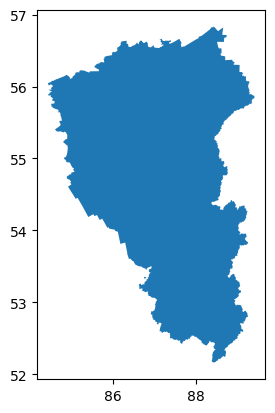

In [3]:
borders = ox.geocode_to_gdf('Кемеровская область, Россия')
borders.plot()

Загрузка точек населенных пунктов

In [4]:
# Тег OSM для зданий
tags = {
    'place': ['city', 'town', 'village'],  #, 'hamlet', 'locality'],
    }

# Словарь полей, которые следует оставить в наборе. Если не использовать, будут сохранены излишние данные
fields = [
    'name',
    'place',
    'geometry',
]

# Загрузка набора данных  из OSM
settlements_points = ox.features_from_polygon(borders.union_all(), tags)
# Приводим геометрию к точке (в локальной СК, во избежание ошибок)
settlements_points = ox.projection.project_gdf(settlements_points)
settlements_points['geometry'] = settlements_points.geometry.centroid
settlements_points = ox.projection.project_gdf(settlements_points, to_latlong=True)
# Оставляем только заданные поля (и при этом имеющиеся в списке полученных)
fields = list(set(settlements_points.columns) & set(fields))
settlements_points = settlements_points[fields]
# Удаляем индекс по типу элемента
settlements_points = settlements_points.reset_index().drop('element', axis=1)
# Устанавливаем индекс 'id'
settlements_points = settlements_points.set_index('id')

# Печать результатов
print('Населенных пунктов:', len(settlements_points))
settlements_points.head()

C:\Users\obsid\AppData\Roaming\Python\Python312\site-packages\osmnx\_overpass.py:267: UserWarning: This area is 46 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Населенных пунктов: 913


,name,place,geometry
id,,,
27505477,Новокузнецк,city,POINT (87.13585 53.75759)
178926370,Тайга,town,POINT (85.63132 56.06507)
191779212,Прокопьевск,city,POINT (86.74921 53.88791)
191908717,Киселёвск,town,POINT (86.63548 54.00499)
191908717,Киселёвск,town,POINT (86.63548 54.00499)


Загрузка пожарных подразделений

In [5]:
# Тег OSM для зданий
tags = {'amenity': 'fire_station'}

# Словарь полей, которые следует оставить в наборе. Если не использовать, будут сохранены излишние данные
fields = [
    'name',
    'operator',
    'fire_station:type',
    'addr:street',
    'addr:housenumber',
    'geometry',
]

# Загрузка набора данных  из OSM
units = ox.features_from_polygon(borders.union_all(), tags)
# Приводим геометрию к точке
units['geometry'] = units.geometry.centroid
# Оставляем только заданные поля (и при этом имеющиеся в списке полученных)
fields = list(set(units.columns) & set(fields))
units = units[fields]
# Удаляем индекс по типу элемента
units = units.reset_index().drop('element', axis=1)
# Заполняем названия подразделений
units['name'] = 'сущ. ' + pd.Series(range(1, len(units) + 1)).astype(str)
# Устанавливаем индекс 'id'
units = units.set_index('id')

# Печать результатов
print('Подразделений:', len(units))
units.head()

C:\Users\obsid\AppData\Roaming\Python\Python312\site-packages\osmnx\_overpass.py:267: UserWarning: This area is 46 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Подразделений: 53


C:\Users\obsid\AppData\Local\Temp\ipykernel_3888\2097302544.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  units['geometry'] = units.geometry.centroid


,operator,name,addr:housenumber,fire_station:type,geometry,addr:street
id,,,,,,
506074900,NaN,сущ. 1,NaN,NaN,POINT (86.44054 54.43532),NaN
1063560909,NaN,сущ. 2,NaN,NaN,POINT (86.22367 54.63829),NaN
1204141457,NaN,сущ. 3,NaN,NaN,POINT (87.86841 52.76413),NaN
1304830390,NaN,сущ. 4,NaN,NaN,POINT (87.7948 53.71559),NaN
1399480141,NaN,сущ. 5,NaN,NaN,POINT (86.65635 53.86747),NaN


:::{.callout-note}

В данном случае данные о ПСЧ выгружаются из OSM. Такие данные редко имеют корректные названия подразделений. Поэтому названия присваиваются по порядку:

    units['name'] = 'сущ. ' + pd.Series(range(1, len(units) + 1)).astype(str)

В реальных расчетах при работе с реальными данными, такая операция не требуется.

:::

Загрузка границ крупных городов

In [6]:
# Список городов
city_list = [
    'Кемерово, Кемеровская область, Россия',
    'город Новокузнецк, Кемеровская область, Россия',
    'Ленинск-Кузнецкий, Кемеровская область, Россия',
]

# Геокодирование городов, для полуения границ
cities = ox.geocode_to_gdf(city_list)
cities['name'] = city_list
cities

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((85.9095 55.31808, 85.90959 55.31797,...",85.909499,55.256576,86.29204,55.544921,202002156,relation,1312868,55.355091,86.087121,place,city,16,0.579964,city,"Кемерово, Кемеровская область, Россия","Kemerovo, Kemerovsky Urban Okrug, Kemerovo Obl..."
1,"POLYGON ((86.85922 53.65112, 86.85939 53.65048...",86.859219,53.640326,87.45095,53.948292,200804424,relation,1437127,53.757590,87.135849,place,city,16,0.579239,city,"город Новокузнецк, Кемеровская область, Россия","Novokuznetsk, Novokuznetsky Urban Okrug, Kemer..."
2,"POLYGON ((86.12103 54.70258, 86.13238 54.69554...",86.121032,54.614967,86.25300,54.719928,200641036,way,92753879,54.665443,86.166115,place,town,18,0.479145,town,"Ленинск-Кузнецкий, Кемеровская область, Россия","Leninsk-Kuznetsky, Leninsk-Kuznetsky Municipal..."


:::{.callout-note}

В данном случае здания будут выгружаться для каждого города в цикле расчета.

:::

Печать карты исходных данных

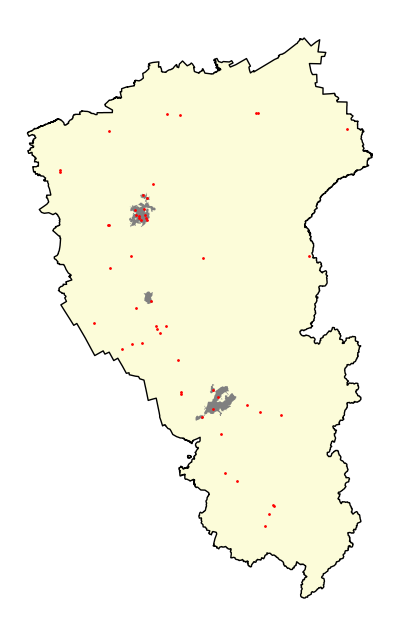

In [7]:
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
cities.plot(ax=ax, color='gray')
units.plot(ax=ax, color='r', markersize=1)
ax.set_axis_off()
plt.show()

## Расчет городов

Перебираем все интересующие нас города и проводим для каждого из них расчет. Используется алгоритм ADD, поэтому в данном случае алгоритм будет собираться и инициироваться отдельно для каждого города, поскольку для каждого из них требуется проводить расчет матрицы прибытия.

In [8]:
from fire_units.settings import BUILDING_FIELDS
from genesis.states import FirstArrivalUnitState, get_atm
from fire_units.metrics import CoverIndexBuilding
from genesis.lscp import LSCP_ADD


# Целевое значение ИП-10
target_ip = 95

# Тег OSM для зданий
tags = {'building': True}
# Словарь полей, которые следует оставить в наборе. Если не использовать, будут сохранены излишние данные
fields = BUILDING_FIELDS
# Количество зданий которые будут учтены при расчет в каждом городе
sample_size = 2000

# Набор данных о узлах ГДС региона
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Размер буферной зоны в метрах
buffer_size = 1000
# Набор полигонов границ городов с буферными зонами
cities_buffer = ox.projection.project_gdf(cities).copy()
cities_buffer = cities_buffer.buffer(buffer_size)
cities_buffer = ox.projection.project_gdf(cities_buffer, to_latlong=True)


# Словарь новых подразделений
new_units = {}
# Цикл перебора всех городов
for id, city in cities.iterrows():
    print('Расчет для города:', city['name'])

    # Получение границ города
    city_boundary = city['geometry']

    # Выборка ПСЧ в пределах полигона границ
    city_units = units.loc[units.geometry.within(city_boundary)].copy()
    print('Подразделений в городе:', len(city_units))


    # Загрузка зданий в городе
    # Загрузка набора данных  из OSM
    buildings = ox.features_from_polygon(city_boundary, tags)
    # Оставляем только данные с геометрией Полигон или Мультиполигон
    buildings = buildings[buildings.geometry.apply(lambda x: x.geom_type).isin(['Polygon', 'MultiPolygon'])]
    # Оставляем только заданные поля (и при этом имеющиеся в списке полученных)
    fields = list(set(buildings.columns) & set(fields))
    buildings = buildings[fields]
    # Удаляем индекс по типу элемента
    buildings = buildings.reset_index().drop('element', axis=1)
    # Устанавливаем индекс 'id'
    buildings = buildings.set_index('id')
    print('Зданий:', len(buildings))


    # Получение подграфа города
    ## Получение полигона с буферной зоной
    borders_buffer = cities_buffer.loc[id]

    ## Получение узлов графа в пределах полигона
    city_nodes = g_nodes.loc[g_nodes['geometry'].within(borders_buffer)]
    ## Получение графа из узлов
    G_city = G.subgraph(city_nodes.index)
    print('Граф', G_city.number_of_nodes(), G_city.number_of_edges())

    
    # Сопоставление с узлами графа
    ## Сопоставление зданий с ближайшими узлами ГДС
    centroids = ox.projection.project_gdf(buildings).geometry.centroid
    buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G_city), 
                                                centroids.x,
                                                centroids.y
                                                )

    ## Сопоставление пожарных подразделений с ближайшими узлами ГДС
    centroids = ox.projection.project_gdf(city_units).geometry.centroid
    city_units['node'] = ox.distance.nearest_nodes(ox.project_graph(G_city), centroids.x, centroids.y)
    ## Формирование словаря подразделений для передачи алгоритму
    units_dict = {k:v for k,v in zip(city_units['node'], city_units['name'])}


    # Расчет матрицы прибытия
    # Определяем количество зданий которые будут рассчитаны
    if len(buildings) <= sample_size:
        data_sample = buildings
    else:
        data_sample = buildings.sample(sample_size)
    ## Вычисление матрицы прибытия
    matrix = get_atm(G,
                 data             = data_sample,
                 cutoff           = 10,
                 )



    # Сборка и инициализация алгоритма:
    ## Выбор алгоритма моделирования параметров прибытия
    state = FirstArrivalUnitState()

    ## Выбор метрики
    metric = CoverIndexBuilding(data_sample, ip_val=10)

    ## Функция остановки
    stop_case = lambda value, **kwargs: value >= target_ip

    ## Функция выполняемая при добавлении новой ПСЧ
    after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric, end='\r')

    ## Сборка и инициализация алгоритма ADD
    add = LSCP_ADD(  
        state_function      = state,
        matrix              = matrix,
        metric_function     = metric,
        stop_case_function  = stop_case,
        after_mclp_function = after_mclp,
        start_names_index   = len(new_units)+1,
    )



    # Расчет:
    best_nodes, best_metric = add(
        env          = G,
        static_nodes = units_dict,
    )



    # Обработка результатов
    print('Количество подразделений необходимых к созданию:', len(best_nodes))
    print('='*80)
    print(' ')

    # Объединение результатов:
    new_units = {**new_units, **best_nodes}
    
# Обработка результатов
print('>>> Количество подразделений необходимых к созданию в городах:', len(new_units))
print('='*80)
print(' ')

Расчет для города: Кемерово, Кемеровская область, Россия
Подразделений в городе: 11
Зданий: 37530
Граф 18174 44431
|########################################| 100.0%
Количество подразделений необходимых к созданию: 4
 
Расчет для города: город Новокузнецк, Кемеровская область, Россия
Подразделений в городе: 4
Зданий: 24860
Граф 13308 33278
|########################################| 100.0%
Количество подразделений необходимых к созданию: 10
 
Расчет для города: Ленинск-Кузнецкий, Кемеровская область, Россия
Подразделений в городе: 1
Зданий: 15068
Граф 3377 9147
|########################################| 100.0%
Количество подразделений необходимых к созданию: 2
 
>>> Количество подразделений необходимых к созданию в городах: 16
 


## Расчет для региона в целом

### Подготовка исходных данных

In [9]:
# Подготовка данных подразделений
## Сопоставление пожарных подразделений с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(units).geometry.centroid
units['node'] = ox.distance.nearest_nodes(ox.project_graph(G), centroids.x, centroids.y)

## Формирование словаря имеющихся подразделений 
existed_units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Объединяем словари имеющихся подразделений и дополнительных для защиты городов
existed_and_new_units_dict = {**existed_units_dict, **new_units}

# Подготовка данных о точках населенных пунктов
## Сопоставление населенных пунктов с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(settlements_points).geometry
settlements_points['node'] = ox.distance.nearest_nodes(ox.project_graph(G), centroids.x, centroids.y)

Расчет матрицы прибытия в населенные пункты

In [10]:
# Сет узлов в которых возможно размещение пожарных подразделений (населенные пункты + имеющиеся подразделения)
targets = set(list(existed_and_new_units_dict.keys()) + list(settlements_points['node']))
print(f'Расчет для {len(settlements_points)} населенных пунктов и {len(targets)} точек размещения')

# Расчет матрицы
matrix = get_atm(G,
                 data       = settlements_points,
                 cutoff     = 20,
                 target_set = targets,
                 )

print('Размер матрицы:', matrix.shape)

# Дополнительная проверка вхождения узла подразделений в матрицу
# В отдельных случаях подразделения могут оказаться расположены так, что ни в один
# населенный пункт они не будут успевать за время 10 или 20 минут. 
# (в результате ошибки)
# Поэтому требуется дополнительная проверка
print('Проверка подразделений', len(existed_and_new_units_dict), end='->')
existed_and_new_units_dict = {k:v for k, v in existed_and_new_units_dict.items() if k in matrix.columns}
print(len(existed_and_new_units_dict))

Расчет для 913 населенных пунктов и 846 точек размещения
|########################################| 100.0%
Размер матрицы: (860, 840)
Проверка подразделений 69->63


Определение количества и оптимальной дислокации ПСЧ с целью достижения **ИП-20 = 95%**, с учетом имеющихся подразделений.

In [ ]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(settlements_points, ip_val=20)

## Функция остановки
stop_case = lambda value, **kwargs: value >= 95      # Расчет проводится для достижения ИП-20 = 95%

## Функция выполняемая при добавлении новой ПСЧ
after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-20:', best_metric, end='\r')

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    ip_val              = 20,               # ВАЖНО! Для ИП отличных от ИП-10, следует указывать явно!
    stop_case_function  = stop_case,
    after_mclp_function = after_mclp,
    names_pattern       = 'село {}',        # Шаблон имен подразделений
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
        static_nodes = existed_and_new_units_dict,
    )


# 4. Печать результатов
print(' ')
print('ИТОГ:', len(best_nodes), best_metric)
print('Имеется подразделений:', len(units),
      'Требуется создать:', len(best_nodes),
      'Всего:', len(units)+len(best_nodes))

 одразделений: 317  ИП-20: 95.071193866374594
ИТОГ: 317 95.07119386637459
Имеется подразделений: 53 Требуется создать: 317 Всего: 370


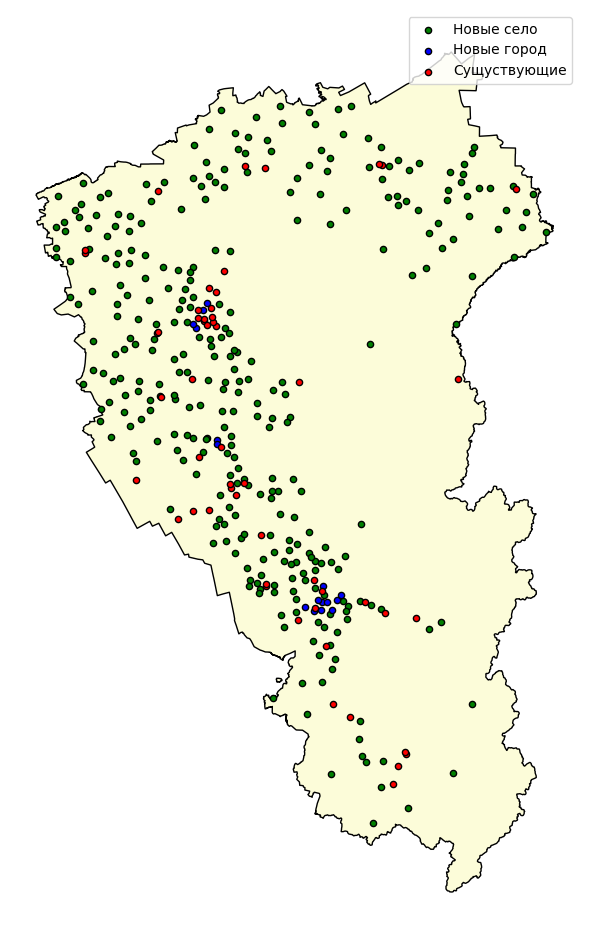

In [12]:
## Печать карты
fig, ax = plt.subplots(figsize=(12,12))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=20, label='Новые село')
g_nodes.loc[new_units.keys()].plot(ax=ax, facecolors='b', edgecolors='k', markersize=20, label='Новые город')
units.plot(ax=ax, facecolors='r', edgecolors='k', markersize=20, label='Сущуствующие')
ax.set_axis_off()
plt.legend()
plt.show()

### Дополнительная проверка отбросом

Эвристические алгоритмы не предлагают точного решения - они лишь предлагают наилучшее из возможных к получению за ограниченное время. Поэтому зачастую предлагаемые решения могут содержать излишние подразделения. Для проверки и отброса таких рекомендаций используется функция `drop_trash_points`.

In [ ]:
from genesis.lscp import drop_trash_points

def stop_case(iteration, value, dynamic_nodes, **kwargs):
    print(iteration, ':', value, len(dynamic_nodes), end='\r')
    return value >= 95

optimal_dynamic_nodes, current_metric = drop_trash_points(
    env = G,
    state_function     = state,
    metric_function    = metric,
    stop_case_function = stop_case,
    dynamic_nodes      = best_nodes,
    static_nodes       = existed_and_new_units_dict,
    )
print('После отброса ошибочных ПСЧ:', len(optimal_dynamic_nodes))

После отброса ошибочных ПСЧ: 237


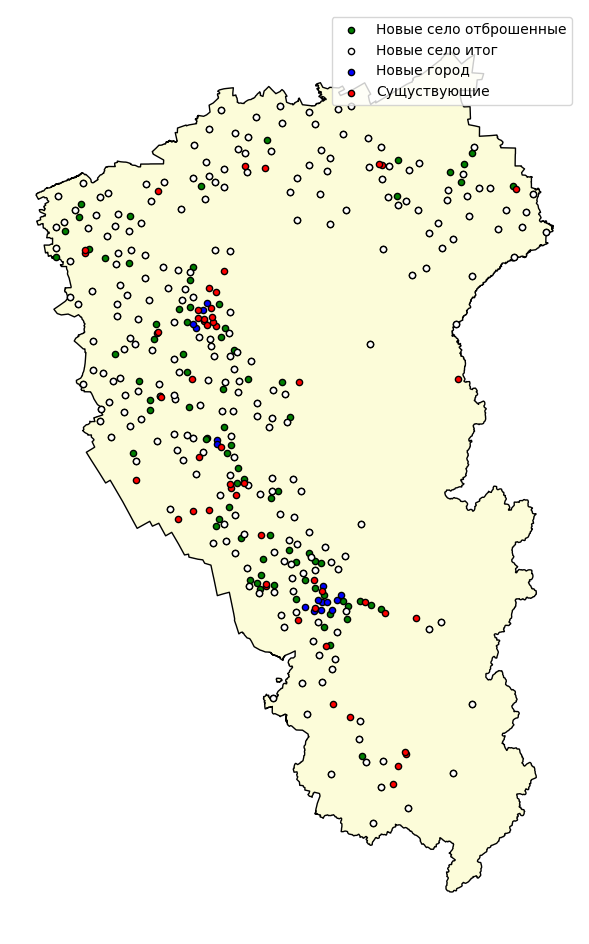

In [18]:
## Печать карты
fig, ax = plt.subplots(figsize=(12,12))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=20, label='Новые село отброшенные')
g_nodes.loc[optimal_dynamic_nodes.keys()].plot(ax=ax, facecolors='w', edgecolors='k', markersize=20, label='Новые село итог')
g_nodes.loc[new_units.keys()].plot(ax=ax, facecolors='b', edgecolors='k', markersize=20, label='Новые город')
units.plot(ax=ax, facecolors='r', edgecolors='k', markersize=20, label='Сущуствующие')
ax.set_axis_off()
plt.legend()
plt.show()

На карте выше зелеными точками отмечены места размещения ПСЧ, которые были отброшены в результате проверки.

Видно что в результате общее количество предложенных мест дислокации уменьшилось с **317** до **237**. Было отброшено, как излишние **80** мест размещения.